# MEDA Resource-Aware Exploratory Data Analysis

This notebook uses a deterministic sol-stratified sample streamed across the complete training Parquet file. Each figure is followed by its own finding, modelling implication and limitation.

In [10]:
from pathlib import Path
import sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
OUTPUTS, MODELS = ROOT/'outputs', ROOT/'models'
sns.set_theme(style='whitegrid')

raw = pd.read_parquet(ROOT/'data/processed/stratified_training_sample.parquet')
print(raw.shape, raw.sol.min(), raw.sol.max(), raw.sol.nunique())
display(raw.head())

(248092, 36) 1.0 100.0 85


,SCLK,LMST,LTST,SOLAR_LONGITUDE_ANGLE,SOLAR_ZENITHAL_ANGLE,ROVER_POSITION_X,ROVER_POSITION_Y,ROVER_POSITION_Z,ROVER_VELOCITY,ROVER_PITCH,...,UPWARD_LW_IRRADIANCE,UPWARD_LW_UNCERTAINTY,RSM_HEAD_OUTSIDE_TIRS_UPWARD_LOOKING_FOV,WHEEL_OUTSIDE_TIRS_DOWNWARD_LOOKING_FOV,SUN_OUTSIDE_TIRS_FOV,ROVER_LOW_TILT,TIRS_GROUND_FOOTPRINT_NOT_IN_SHADOW,ROVER_HGA_OFF,SKYCAM_OFF,ROVER_STILL
0,667042464,00001M16:05:31.315,0001 15:28:01,101.03,53.33,-0.0,-0.0,0.64,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,667042465,00001M16:05:32.289,0001 15:28:02,101.03,53.33,-0.0,-0.0,0.64,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,667042466,00001M16:05:33.262,0001 15:28:03,101.02,53.34,-0.0,-0.0,0.64,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,667042467,00001M16:05:34.235,0001 15:28:04,101.02,53.34,-0.0,-0.0,0.64,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,667042468,00001M16:05:35.208,0001 15:28:05,101.02,53.34,-0.0,-0.0,0.64,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Schema and target audit

The rebuilt sample contains **248,092 observations across 85 sols (1-100)**, avoiding the original first-row-group bias. The ten fully absent fields, including `VOLUME_MIXING_RATIO_UNCERTAINTY`, are unusable in this training period; two humidity fields are intermittently observed. These patterns justify missingness indicators and algorithms that tolerate unavailable sensors.

In [11]:
audit = pd.DataFrame({'dtype':raw.dtypes.astype(str),'missing_percent':raw.isna().mean()*100,'unique':raw.nunique(dropna=True)}).sort_values('missing_percent',ascending=False)
display(audit)

,dtype,missing_percent,unique
VOLUME_MIXING_RATIO_UNCERTAINTY,float64,100.000000,0
MASTHEAD_AZIMUTH,float64,100.000000,0
PRESSURE_UNCERTAINTY,float64,100.000000,0
MASTHEAD_ELEVATION,float64,100.000000,0
WHEEL_OUTSIDE_TIRS_DOWNWARD_LOOKING_FOV,float64,100.000000,0
ROVER_HGA_OFF,float64,100.000000,0
SKYCAM_OFF,float64,100.000000,0
LOCAL_RELATIVE_HUMIDITY_UNCERTAINTY,float64,99.864969,114
VOLUME_MIXING_RATIO,float64,89.176193,3776
LOCAL_RELATIVE_HUMIDITY,float64,60.772617,1442


## Figure 1 - Pressure distribution

**Finding.** Pressure has mean **748.65 Pa**, median **749.77 Pa**, standard deviation **10.33 Pa**, and range **714.43-771.39 Pa**. The distribution combines seasonal and diurnal states rather than representing independent identical observations.

**Modelling implication.** Report errors in pascals as well as squared error, and include cyclic seasonal/time features.

**Limitation.** A histogram removes temporal order and cannot demonstrate future-sol generalisation.

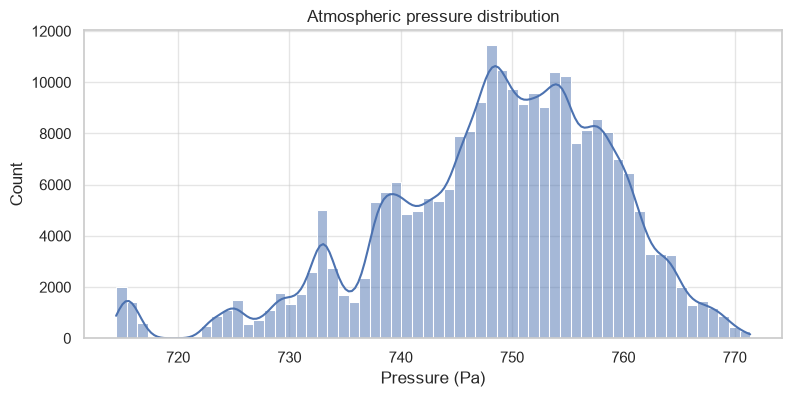

count    248092.000000
mean        748.646809
std          10.334145
min         714.430000
25%         742.660000
50%         749.770000
75%         756.010000
max         771.390000
Name: PRESSURE, dtype: float64

In [12]:
plt.figure(figsize=(9,4)); sns.histplot(raw.PRESSURE,bins=60,kde=True); plt.xlabel('Pressure (Pa)'); plt.title('Atmospheric pressure distribution'); plt.show(); display(raw.PRESSURE.describe())

## Figure 2 - Missingness

**Finding.** The most incomplete feature is **VOLUME_MIXING_RATIO_UNCERTAINTY (100.0%)**; multiple sensor channels are structurally absent rather than randomly missing.

**Modelling implication.** Entirely absent columns carry no training information, while partially observed channels require missing-aware preprocessing and explicit missing-count features.

**Limitation.** Missingness percentage alone cannot distinguish instrument scheduling, faults and environmental censoring.

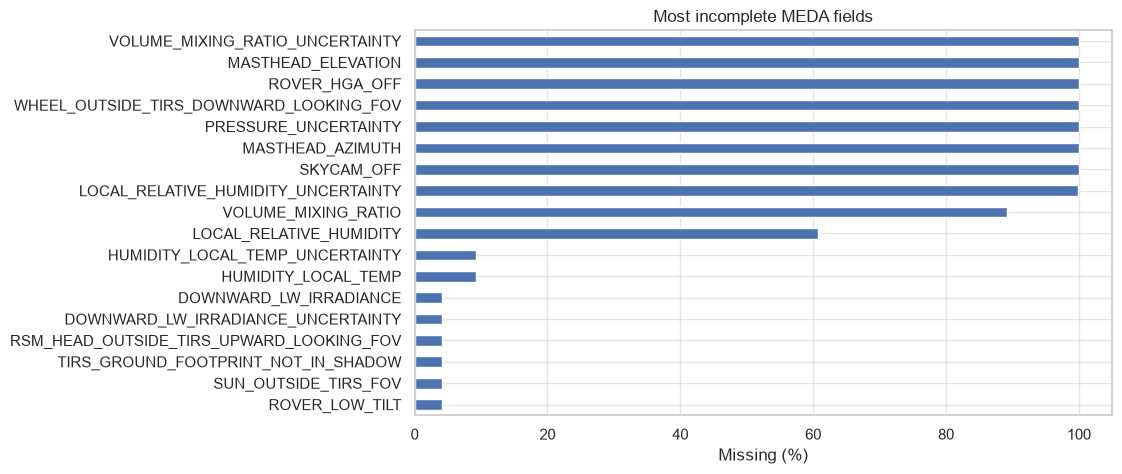

In [13]:
m=raw.isna().mean().mul(100).sort_values(ascending=False).head(18).sort_values(); plt.figure(figsize=(9,5)); m.plot.barh(); plt.xlabel('Missing (%)'); plt.title('Most incomplete MEDA fields'); plt.show()

## Figure 3 - Seasonal movement

**Finding.** Mean pressure changes from **715.24 Pa at sol 1** to **760.07 Pa at sol 100**, and it is not monotonic across the complete period.

**Modelling implication.** Random splitting leaks nearby seasonal states. Ordered temporal partitions and cyclic solar-longitude terms are required.

**Limitation.** Mean-by-sol suppresses short-lived vortices and within-sol tidal variability.

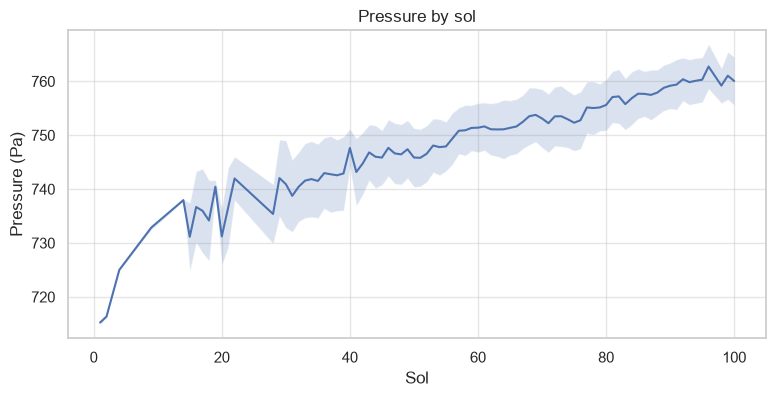

In [14]:
g=raw.groupby('sol').PRESSURE.agg(['mean','std']); plt.figure(figsize=(9,4)); plt.plot(g.index,g['mean']); plt.fill_between(g.index,g['mean']-g['std'],g['mean']+g['std'],alpha=.2); plt.xlabel('Sol'); plt.ylabel('Pressure (Pa)'); plt.title('Pressure by sol'); plt.show()

## Figure 4 - Diurnal pressure cycle

**Finding.** Pressure varies systematically with local mean solar time, consistent with diurnal and semidiurnal thermal tides described for Jezero crater.

**Modelling implication.** First-, second- and third-order Fourier terms are added for LMST and LTST rather than treating clock strings as categories.

**Limitation.** Hourly aggregation combines all sols and does not prove that tidal amplitude is seasonally constant.

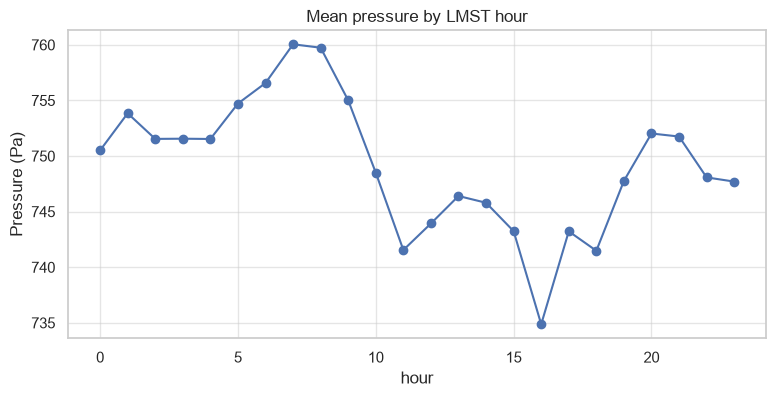

In [15]:
hour=raw.LMST.str.extract(r'M(\d{1,2}):')[0].astype(float); d=pd.DataFrame({'hour':hour,'PRESSURE':raw.PRESSURE}).groupby('hour').PRESSURE.mean(); plt.figure(figsize=(9,4)); d.plot(marker='o'); plt.ylabel('Pressure (Pa)'); plt.title('Mean pressure by LMST hour'); plt.show()

## Figure 5 - Correlation structure

**Finding.** Solar geometry, mission time and radiative measurements show the strongest marginal relationships with pressure, supporting a combined seasonal, diurnal and environmental model.

**Modelling implication.** Both regularised linear harmonics and nonlinear ensembles are compared; correlation is not used as a feature-selection rule by itself.

**Limitation.** Pearson correlation measures linear association, is affected by shared time trends, and does not establish causality.

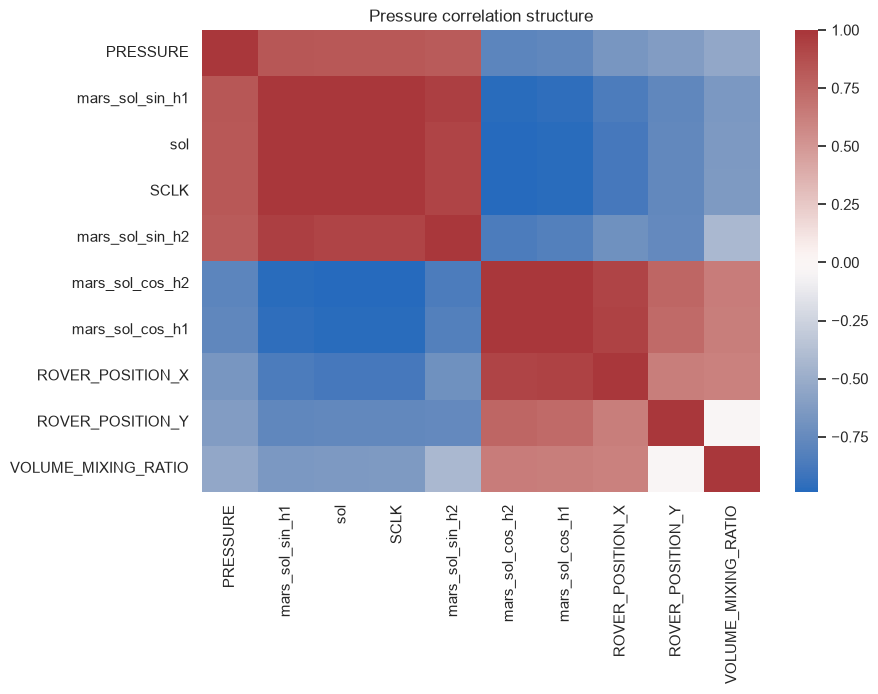

In [16]:
from src.meda_pipeline import build_features
X=build_features(raw); z=X.copy(); z['PRESSURE']=raw.PRESSURE.to_numpy(); strongest=z.corr(numeric_only=True).PRESSURE.abs().sort_values(ascending=False).head(10).index; plt.figure(figsize=(9,6)); sns.heatmap(z[list(strongest)].corr(),cmap='vlag',center=0); plt.title('Pressure correlation structure'); plt.show()

## EDA hand-off

The three strongest design consequences are: preserve complete sol coverage, validate in temporal order, and encode the physical seasonal/thermal-tide cycles. Structural missingness additionally requires one shared missing-aware preprocessing contract. These choices directly address the original local/Kaggle disagreement.